# Loading Libraries And Data

In [38]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
import numpy as np
import re

In [ ]:
pd.set_option('display.max_colwidth', None)

file_path= "../data/digikala-comments.csv"
df = pd.read_csv(file_path, encoding="utf-8")
df_sample = df.sample(n=200_000, random_state=42)

# Basic Information

In [ ]:
df.head()

In [ ]:
df.describe()

In [ ]:
df.info()

In [ ]:
df.shape

# Missing Values

In [ ]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_percent = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

missing_df = pd.concat([missing_values, missing_percent], axis=1, keys=['count', 'percent'])
missing_df[missing_df['count'] > 0]

# Target Distribution

In [ ]:
opinion = df["recommendation_status"].value_counts()

labels = opinion.index
counts = opinion.values

color_map = {
    "recommended": "green",
    "not_recommended": "red",
    "no_idea": "gray"
}

colors = [color_map.get(label, "blue") for label in labels]
plt.figure(figsize=(7, 4))
fig = go.Figure(
    data=[
        go.Pie(
            labels=labels,
            values=counts
        )
    ]
)

fig.update_layout(
    title_text="Distribution of Recommendation Status"
)

fig.update_traces(
    hoverinfo="label+percent",
    textinfo="value",
    textfont_size=30,
    marker=dict(
        colors=colors,
        line=dict(color="black", width=1)
    )
)

fig.update_layout(width=700,height=400)

fig.show()

# Rate Analysis

In [ ]:
invalid_rate = df[df["rate"] > 5]

print("Number of invalid rates:", len(invalid_rate))
print("Percentage:", len(invalid_rate) / len(df) * 100)

In [ ]:
df[df['rate'] > 5]
df.loc[df['rate'] > 5, 'rate'] = np.nan
fig = px.histogram(df, x="rate", nbins=50, title="Distribution of Ratings")
fig.update_layout(width=700,height=400)
fig.show()

In [ ]:
avg_rate_per_class = df.groupby("recommendation_status")["rate"].mean().reset_index()

fig_bar = px.bar(
    avg_rate_per_class,
    x="recommendation_status",
    y="rate",
    color="rate",
    title="Average Rate by Recommendation Status"
)

fig_bar.update_layout(width=700,height=400)

fig_bar.show()

In [ ]:
fig_box = px.box(
    df,
    x="recommendation_status",
    y="rate",
    title="Rate Distribution by Recommendation Status"
)

fig_box.update_layout(width=700,height=400)

fig_box.show()

# Review Length

In [30]:
df["body_length"] = df["body"].str.len()

print(f"تعداد نظرات بدون body: {df['body_length'].isna().sum()}")
print(df["body_length"].describe())

df_sample["body_length"] = df_sample["body"].str.len()

fig = px.histogram(
    df_sample,
    x="body_length",
    title="Distribution of Review Length",
    nbins=50
)

fig.update_xaxes(
    range=[0, df["body_length"].quantile(0.99)]
)

fig.update_layout(width=700,height=400)

fig.show()

تعداد نظرات بدون body: 637
count    6.155652e+06
mean     4.839835e+01
std      6.435065e+01
min      1.000000e+00
25%      1.500000e+01
50%      2.900000e+01
75%      5.700000e+01
max      4.000000e+03
Name: body_length, dtype: float64


In [31]:
fig = px.box(
    df_sample.dropna(subset=["body_length"]),
    x="recommendation_status",
    y="body_length",
    title="Review Length by Recommendation Status"
)

fig.update_yaxes(range=[0, df["body_length"].quantile(0.99)])

fig.update_layout(width=700,height=400)

fig.show()

Output hidden; open in https://colab.research.google.com to view.

# Buyer Analysis

is_buyer
True     0.950915
False    0.049085
Name: proportion, dtype: float64


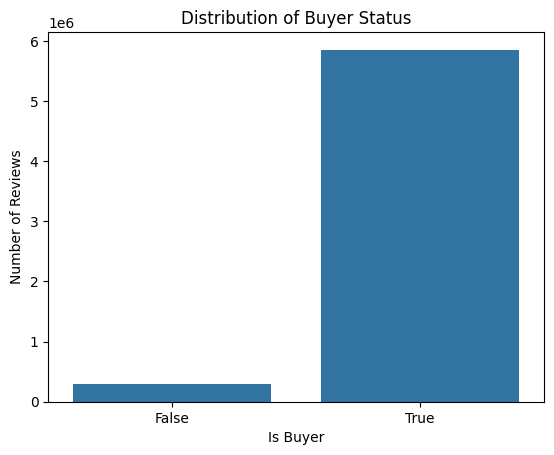

   is_buyer  avg_rate  num_reviews
0     False  4.045022       302181
1      True  3.627381      5854108


recommendation_status   no_idea  not_recommended  recommended
is_buyer                                                     
True                   0.112911         0.095955     0.791134


In [50]:
print(df["is_buyer"].value_counts(normalize=True))

sns.countplot(x=df["is_buyer"])
plt.title("Distribution of Buyer Status")
plt.xlabel("Is Buyer")
plt.ylabel("Number of Reviews")
plt.show()

buyer_sentiment = df.groupby("is_buyer").agg(
    avg_rate=("rate", "mean"),
    num_reviews=("is_buyer", "size")
).reset_index()
print(buyer_sentiment)

fig = px.bar(
    buyer_sentiment,
    x="is_buyer",
    y="avg_rate",
    color="num_reviews",
    title="Average Rate by Buyer Status"
)

fig.update_layout(width=700,height=400)

fig.show()

print(pd.crosstab(df["is_buyer"], df["recommendation_status"], normalize='index'))

# Seller Analysis

In [32]:
seller_stats = df.groupby("seller_title").agg(
    avg_rate=("rate", "mean"),
    num_reviews=("seller_title", "size")
).reset_index()

top_sellers = seller_stats.sort_values("num_reviews",ascending=False).head(10)

figure = px.bar(
    top_sellers,
    x="seller_title",
    y="avg_rate",
    color="num_reviews",
    title="Average Rate of Top 10 Sellers by Number of Reviews",
    text="avg_rate"
)

figure.update_layout(width=700,height=400)

figure.show()

# Likes / Dislikes

In [34]:
fig = px.histogram(
    df,
    x="likes",
    title="Distribution of Likes (log scale)",
    log_y=True
)

fig.update_layout(width=700,height=400)

fig.show()

Output hidden; open in https://colab.research.google.com to view.

In [35]:
fig = px.histogram(
    df,
    x="dislikes",
    title="Distribution of Dislikes (log scale)",
    log_y=True
)

fig.update_layout(
    width=700,
    height=400
)

fig.show()

Output hidden; open in https://colab.research.google.com to view.

# Duplicate Check

In [36]:
duplicate_text = df[df.duplicated(subset=['title', 'body'], keep=False)]
print(f"تعداد ردیف‌های با متن تکراری: {len(duplicate_text)}")
duplicate_text.sort_values('body').head()

تعداد ردیف‌های با متن تکراری: 1645169


,id,title,body,created_at,rate,recommendation_status,is_buyer,product_id,advantages,disadvantages,likes,dislikes,seller_title,seller_code,true_to_size_rate,body_length
747705,31637841,NaN,\t\nتو این رنج قیمت عالیه....,28 بهمن 1400,5.0,recommended,True,3786446,NaN,NaN,0,0,نگزیت,CCZJS,NaN,27.0
1589514,31637845,NaN,\t\nتو این رنج قیمت عالیه....,28 بهمن 1400,5.0,recommended,True,1100403,NaN,NaN,0,0,سایه آرت,AJCUU,NaN,27.0
2253581,31637774,NaN,\t\nتو این رنج قیمت عالیه....,28 بهمن 1400,5.0,recommended,True,4475826,NaN,NaN,0,0,مارال بیوتی,CZATF,NaN,27.0
3164428,36436547,NaN,\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nخیلی خوب و عالی هست خریدشو توصیه میکنم\n\n,12 تیر 1401,3.0,no_idea,True,2509893,NaN,NaN,0,0,نوشه شاپ,AVZRU,NaN,59.0
1710439,36436248,NaN,\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nخیلی خوب و عالی هست خریدشو توصیه میکنم\n\n,12 تیر 1401,3.0,recommended,True,2076174,NaN,NaN,0,0,وان کالا,CSZ49,NaN,59.0


# Text Analysis

In [37]:
text_df = df_sample[["body", "recommendation_status"]].dropna().copy()

text_df["body"] = text_df["body"].astype(str)

In [39]:
emoji_pattern = re.compile(
    "["
    "\U0001F300-\U0001F5FF"
    "\U0001F600-\U0001F64F"
    "\U0001F680-\U0001F6FF"
    "\U0001F700-\U0001F77F"
    "\U0001F780-\U0001F7FF"
    "\U0001F800-\U0001F8FF"
    "\U0001F900-\U0001F9FF"
    "\U0001FA00-\U0001FAFF"
    "\u2600-\u26FF"
    "\u2700-\u27BF"
    "]+"
)

has_emoji = text_df["body"].apply(
    lambda x: bool(emoji_pattern.search(x))
)

print("Reviews containing emoji:", has_emoji.sum())
print(f"Percentage: {has_emoji.mean() * 100:.2f}%")

Reviews containing emoji: 1293
Percentage: 0.76%


In [40]:
has_english = text_df["body"].str.contains(
    r"[A-Za-z]",
    regex=True
)

print("Reviews containing English characters:", has_english.sum())
print(f"Percentage: {has_english.mean() * 100:.2f}%")

Reviews containing English characters: 1134
Percentage: 0.66%


In [41]:
has_numbers = text_df["body"].str.contains(
    r"\d",
    regex=True
)

print("Reviews containing numbers:", has_numbers.sum())
print(f"Percentage: {has_numbers.mean() * 100:.2f}%")

Reviews containing numbers: 7955
Percentage: 4.66%


# Time Analysis

In [42]:
print(df["created_at"].head())
print(df["created_at"].dtype)

0    23 شهریور 1402
1       16 تیر 1399
2     26 مرداد 1401
3     28 اسفند 1399
4    12 شهریور 1402
Name: created_at, dtype: object
object


In [45]:
df["year"] = df["created_at"].str.extract(r"(\d{4})")

df["month"] = df["created_at"].str.extract(
    r"(فروردین|اردیبهشت|خرداد|تیر|مرداد|شهریور|مهر|آبان|آذر|دی|بهمن|اسفند)"
)

month_order = {
    "فروردین": 1,
    "اردیبهشت": 2,
    "خرداد": 3,
    "تیر": 4,
    "مرداد": 5,
    "شهریور": 6,
    "مهر": 7,
    "آبان": 8,
    "آذر": 9,
    "دی": 10,
    "بهمن": 11,
    "اسفند": 12
}

df["month_num"] = df["month"].map(month_order)

df[["created_at", "year", "month"]].head()

,created_at,year,month
0,23 شهریور 1402,1402,شهریور
1,16 تیر 1399,1399,تیر
2,26 مرداد 1401,1401,مرداد
3,28 اسفند 1399,1399,اسفند
4,12 شهریور 1402,1402,شهریور


In [47]:
monthly_reviews = (
    df.groupby(["year", "month"])
      .size()
      .reset_index(name="num_reviews")
)

monthly_reviews["year_month"] = (
    monthly_reviews["year"] + "/" + monthly_reviews["month"]
)

monthly_reviews = monthly_reviews.sort_values(["year", "month"])

fig = px.line(
    monthly_reviews,
    x="year_month",
    y="num_reviews",
    markers=True,
    title="Number of Reviews Over Time"
)

fig.update_layout(
    width=800,
    height=450,
    xaxis_title="Year / Month",
    yaxis_title="Number of Reviews"
)

fig.show()

In [48]:
monthly_rate = (
    df.groupby(["year", "month"])["rate"]
      .mean()
      .reset_index(name="avg_rate")
)

monthly_rate["year_month"] = (
    monthly_rate["year"] + "/" + monthly_rate["month"]
)

monthly_rate = monthly_rate.sort_values(["year", "month"])

fig = px.line(
    monthly_rate,
    x="year_month",
    y="avg_rate",
    markers=True,
    title="Average Rate Over Time"
)

fig.update_layout(
    width=800,
    height=450,
    xaxis_title="Year / Month",
    yaxis_title="Average Rate"
)

fig.show()

# Conclusion / Summary

In [49]:
print("EDA Summary")
print("-" * 40)

print(f"Total number of reviews: {len(df):,}")
print(f"Missing review bodies: {df['body'].isna().sum():,}")
print(f"Invalid rates (>5): {(df['rate'] > 5).sum():,}")
print(f"Duplicate reviews (title + body): {df.duplicated(subset=['title', 'body']).sum():,}")

EDA Summary
----------------------------------------
Total number of reviews: 6,156,289
Missing review bodies: 637
Invalid rates (>5): 0
Duplicate reviews (title + body): 1,467,643


## 12. Conclusion / Summary

The exploratory data analysis provided an overview of the Persian Digikala review dataset and identified its main characteristics.

- The dataset contains 6,156,289 reviews, providing a large collection of Persian product reviews for sentiment analysis.
- Only 637 reviews have missing values in the `body` column. These records should be considered during the preprocessing stage.
- All values in the `rate` column are within the expected rating range, so no invalid rating values were identified.
- A total of 1,467,643 duplicate reviews were identified based on the combination of `title` and `body`. The treatment of these duplicates should be considered during preprocessing to reduce potential redundancy in the training data.
- Review lengths vary considerably, indicating that the text preprocessing and modeling pipeline should be able to handle reviews of different lengths.
- The distribution of `recommendation_status` was examined as the target variable for the sentiment classification task.
- Buyer status, seller information, likes, and dislikes were also explored to provide a better understanding of the dataset.
- The presence of emojis, English characters, and numerical characters in reviews was examined and should be considered when designing the text preprocessing pipeline.
- The `created_at` column was analyzed to examine the temporal distribution of reviews.

Overall, the EDA identified the main characteristics and potential data-quality issues of the dataset. The findings provide a basis for designing the preprocessing pipeline, including handling missing review texts, considering duplicate reviews, and applying appropriate Persian text preprocessing techniques before model training.